In [1]:
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os


d:\GenerativeAI\LangGraph_Learning\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
load_dotenv()

# 1. Initialize Model with Retries
# This helps handle the 429 error by waiting and trying again automatically
llm = ChatMistralAI(
    model="mistral-small-latest",
    
)

In [3]:
from pydantic import BaseModel,Field

class graph_schema(BaseModel):
    topic:str=Field(description="The topic of the langhraph")
    post:str=Field(description="The Linkedin post content")
    curated_post:str=Field(description="The curated Linkedin post content")



demo_obj=graph_schema(
    topic="how the water is important to us",
    post="Water is very important for the human being to live on the earth we can live without it" ,
    curated_post="Water is also important for the plants,animals and to make the balance in the enviroment"
)


print(demo_obj)


topic='how the water is important to us' post='Water is very important for the human being to live on the earth we can live without it' curated_post='Water is also important for the plants,animals and to make the balance in the enviroment'


In [4]:
def create_post(state:graph_schema)->graph_schema:
    topic=state.topic

    post=llm.invoke(f"Write a Linkedin post about {topic}").content

    state.post=post
    return state




def curate_post(state:graph_schema)->graph_schema:
    post=state.post

    curated_post=llm.invoke(f"Curate the following Linkedin post with GenZ tone :{post}").content

    state.curated_post=curated_post

    return state


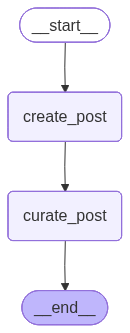

In [6]:
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display
graph=StateGraph(graph_schema)

graph.add_node("create_post",create_post)
graph.add_node("curate_post",curate_post)

graph.add_edge(START,"create_post")
graph.add_edge("create_post","curate_post")
graph.add_edge("curate_post",END)


pydantic_graph=graph.compile()


Image(pydantic_graph.get_graph().draw_mermaid_png())



In [7]:
pydantic_graph.invoke(
    {"topic":"the importance of data privacy in the digital age",
     "post":"",
     "curated_post":""}
)

{'topic': 'the importance of data privacy in the digital age',
 'post': '**🔒 The Silent Guardian: Why Data Privacy Matters in the Digital Age 🔒**\n\nIn a world where our lives—both personal and professional—are increasingly digitized, data privacy isn’t just a buzzword—it’s a fundamental right. Every time we share, store, or process information online, we leave behind a digital footprint that can be exploited, misused, or even weaponized.\n\n**Why does this matter?**\n✅ **Protection Against Cyber Threats** – Data breaches can lead to identity theft, financial fraud, and reputational damage.\n✅ **Trust & Compliance** – Businesses handling customer data must adhere to regulations like GDPR, CCPA, and others to avoid hefty fines and lost trust.\n✅ **Ethical Responsibility** – As professionals, we have a duty to safeguard user data, whether we’re developers, marketers, or executives.\n✅ **Personal Security** – Our online habits—from passwords to location tracking—can reveal more about us t